**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 8. Reinforcement learning: DDPG

Deep Deterministic Policy Gradient across the four economies, both observation specifications and both
actor variants, with the paper's architecture search and agent selection.

**Inputs:** the artifacts of notebooks `00` to `07`. **Outputs:** `artifacts/rl/ddpg/*.pt`, one trained
policy per cell.

In [11]:
import pandas as pd

import autofed as af
from autofed import plots, rl

nb = af.NotebookSession("08_rl_ddpg", number=8, title="Reinforcement learning: DDPG")

lab = rl.PolicyLab.load(
    nb.workspace.artifacts
)  # economies of notebooks 01-06, settings of notebook 07
cfg = lab.config
OBS_SPECS = ["x1", "x2"]
LOSS_COLUMNS = {
    "dev2 pi": r"$\Delta^2(\pi^*, \pi_t)$",
    "dev2 y": r"$\Delta^2(y^*, y_t)$",
    "dev2 di": r"$\Delta^2(\Delta i_t)$",
}
PATH_NOTE = (
    "Simulated from the first two estimation-window quarters under freshly drawn shocks; every"
    " policy faces the same shocks within an economy. Not a historical counterfactual."
)


def slug(name: str) -> str:
    return name.lower().replace("-", "_").replace(" ", "_")


print(
    "Economies:",
    ", ".join(lab.env_names),
    "| frames per run:",
    cfg.total_timesteps,
    "| seed:",
    cfg.seed,
)

POLICY_VARIANTS = ["linear", "nonlinear"]

Economies: SVAR, TVP-SVAR-SV, NARX, NSSM | frames per run: 12500 | seed: 2026


## The algorithm

DDPG (Lillicrap et al., 2015) is an off-policy deterministic-actor / Q-critic algorithm. The objective
is TorchRL's `DDPGLoss` with target copies of both the actor and the critic, a one-step TD target and a
squared-error critic loss. The two actor networks carry no output squashing, so the policy
parameterisation matches H&T (2021, eq. 12-13) directly:

$$P_t = i_t = \max\{f(x_t^z), 0\}, \qquad f(x_t^z) = \alpha_0 + \sum_{j=1}^{q} \delta_j G(\beta_j' x_t^z + \alpha_j),$$

with $G = \text{purelin}$ and $q = 1$ for the linear variant and $G = \tanh$ for the nonlinear
variant. The ZLB ReLU of eq. 12 is realised by the action-space clipping at $a = -1$ (which maps
to $i_t = 0$). Exploration adds Gaussian noise to the actor's output and projects the result back onto
the action spec (`AdditiveGaussianModule`).

We train DDPG across all 16 (env $\times$ obs spec $\times$ policy variant) cells, with the
hidden-node search over the critic and (for nonlinear) actor architectures defined in
`cfg.critic_node_grid` and `cfg.actor_node_grid`.

#### Off-policy training loop

DDPG and SAC share one loop. A TorchRL `Collector` steps the environment with the behaviour policy
(uniformly random actions for the first `LEARNING_STARTS` frames), every frame goes into a
`TensorDictReplayBuffer`, and after the warm-up each collected frame is followed by one gradient step
on a uniformly sampled minibatch and one Polyak update of the target networks. The loss module owns
the networks' parameters, so the collector's policy sees every update without any explicit
synchronisation.

#### Agent selection and candidate checkpoints

`EpisodeTracker` reads the episode return and length that the `RewardSum` and `StepCounter` transforms
attach to every collected frame, and saves candidate checkpoints of the actor that satisfy the
H&T (2021) selection criterion (ER/ES > -50 during the search phase; the steady-state-reward
tiebreaker picks the winner). The strict H&T threshold of -4 is preserved in the constants block for
documentation but the search-phase looseness is needed because the NSSM extrapolates badly under any
policy.

## Training

`train_ddpg_cell` runs the architecture search for one (economy, observation, variant) cell: one agent
per (critic size, actor size) pair, every run from the same seed, each reduced to its best checkpoint by
steady-state reward. The winning architecture's policy is kept and saved.

In [12]:
cells, logs = [], {}
for env_name in lab.env_names:
    for obs_spec in OBS_SPECS:
        for variant in POLICY_VARIANTS:
            cell, log = rl.train_ddpg_cell(lab, env_name, obs_spec, variant)
            cells.append(cell)
            log.index = [
                f"critic {c}, actor {a}"
                for c, a in zip(log.pop("Critic nodes"), log.pop("Actor nodes"))
            ]
            logs[f"{env_name}: {obs_spec} {variant}"] = log
saved = rl.save_cells(cells, nb.artifacts("rl", "ddpg"), sac_hidden=cfg.sac_hidden)
print(
    f"Trained and saved {len(saved)} DDPG cells to"
    f" {saved[0].parent.relative_to(nb.workspace.root)}"
)

Trained and saved 16 DDPG cells to artifacts/rl/ddpg


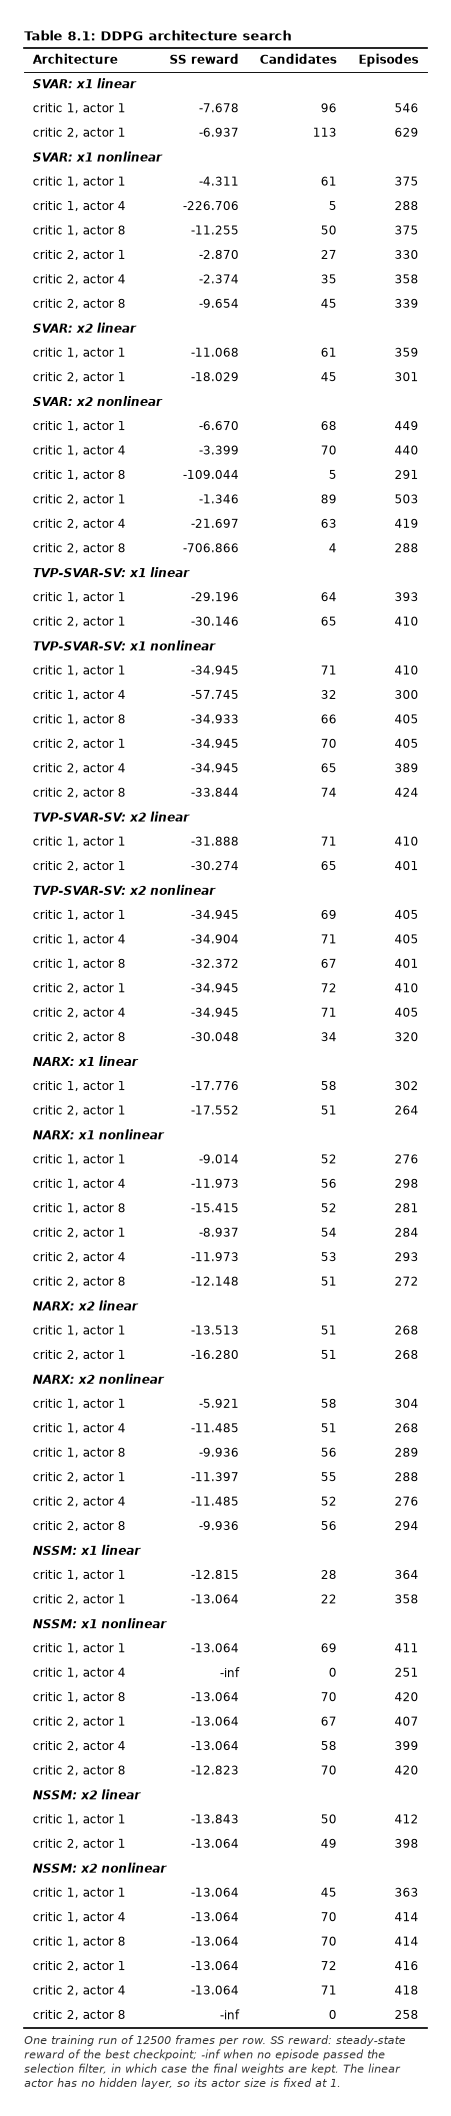

In [13]:
search_log = pd.concat(logs, names=["Cell", "Architecture"]).astype(
    {"Candidates": int, "Episodes": int}
)
nb.table(
    search_log,
    "architecture_search",
    "DDPG architecture search",
    fontsize=8.0,
    note=(
        f"One training run of {cfg.total_timesteps} frames per row. SS reward: steady-state"
        " reward of the best checkpoint; -inf when no episode passed the selection filter, in"
        " which case the final weights are kept. The linear actor has no hidden layer, so its"
        " actor size is fixed at 1."
    ),
)

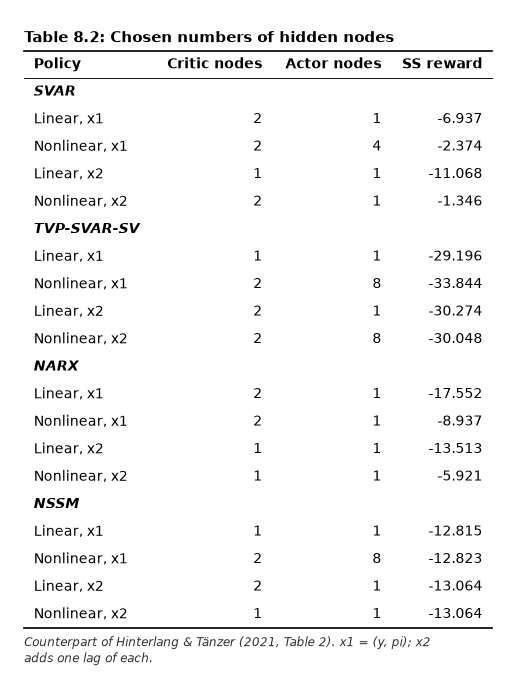

In [14]:
chosen = pd.DataFrame.from_dict(
    {
        (c.env_name, f"{c.variant.capitalize()}, {c.obs_spec}"): {
            "Critic nodes": c.critic_nodes,
            "Actor nodes": c.actor_nodes,
            "SS reward": c.steady_state_reward,
        }
        for c in cells
    },
    orient="index",
).astype({"Critic nodes": int, "Actor nodes": int})
chosen.index = pd.MultiIndex.from_tuples(chosen.index, names=["Economy", "Policy"])
nb.table(
    chosen,
    "chosen_architectures",
    "Chosen numbers of hidden nodes",
    note=(
        "Counterpart of Hinterlang & Tänzer (2021, Table 2). x1 = (y, pi); x2 adds one lag of"
        " each."
    ),
)

#### Policy linearisation and plotting utilities

`linearise_policy` evaluates the *clipped* policy on a $(\pi, y)$ grid and fits OLS to recover
effective Taylor coefficients in the level form of H&T Table 4,
$i = \alpha_0 + \beta_\pi \pi + \beta_y y$, so that they read directly against the reference rules.
We use this for **all** algorithm cells (linear and nonlinear actors, plus Q-learning) so the reported
coefficients reflect the policy the environment actually sees, rather than raw actor weights that may
have grown past the action-space clip during training. The grid is evaluated in one batched forward
pass.

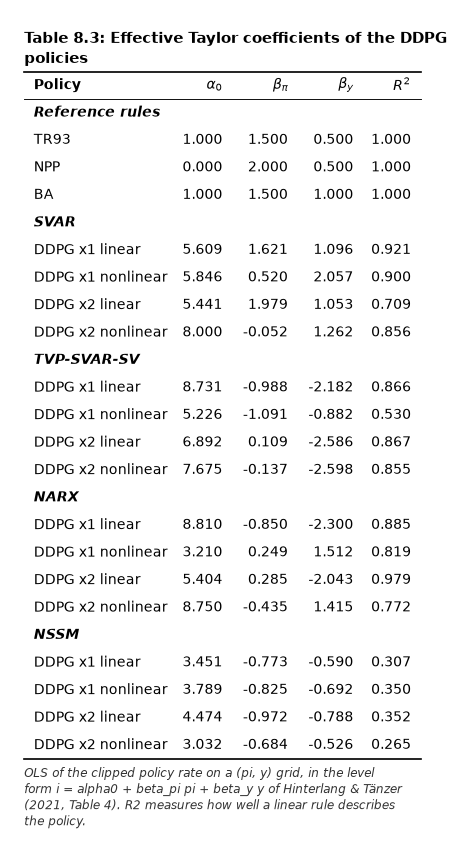

In [15]:
nb.table(
    rl.coefficient_table(cells),
    "taylor_coefficients",
    "Effective Taylor coefficients of the DDPG policies",
    note=(
        "OLS of the clipped policy rate on a (pi, y) grid, in the level form i = alpha0 +"
        " beta_pi pi + beta_y y of Hinterlang & Tänzer (2021, Table 4). R2 measures how well a"
        " linear rule describes the policy."
    ),
)

## Training curves, reaction functions and simulated paths

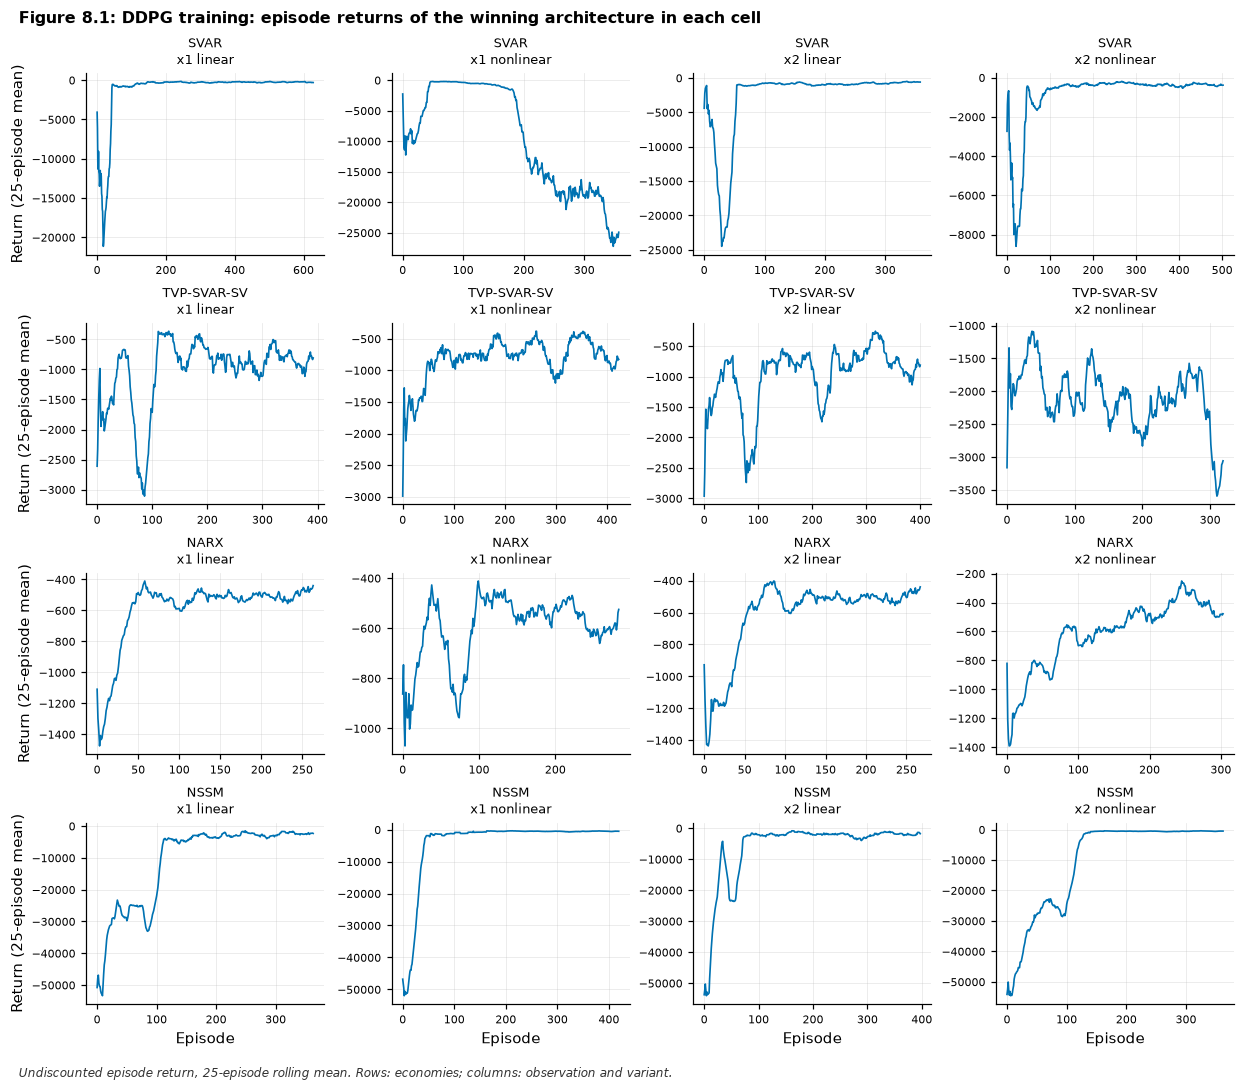

In [16]:
fig = plots.training_curves(
    {f"{c.env_name}\n{c.obs_spec} {c.variant}": c.training_rewards for c in cells}, window=25
)
nb.figure(
    fig,
    "training_curves",
    "DDPG training: episode returns of the winning architecture in each cell",
    note=(
        "Undiscounted episode return, 25-episode rolling mean. Rows: economies; columns:"
        " observation and variant."
    ),
)

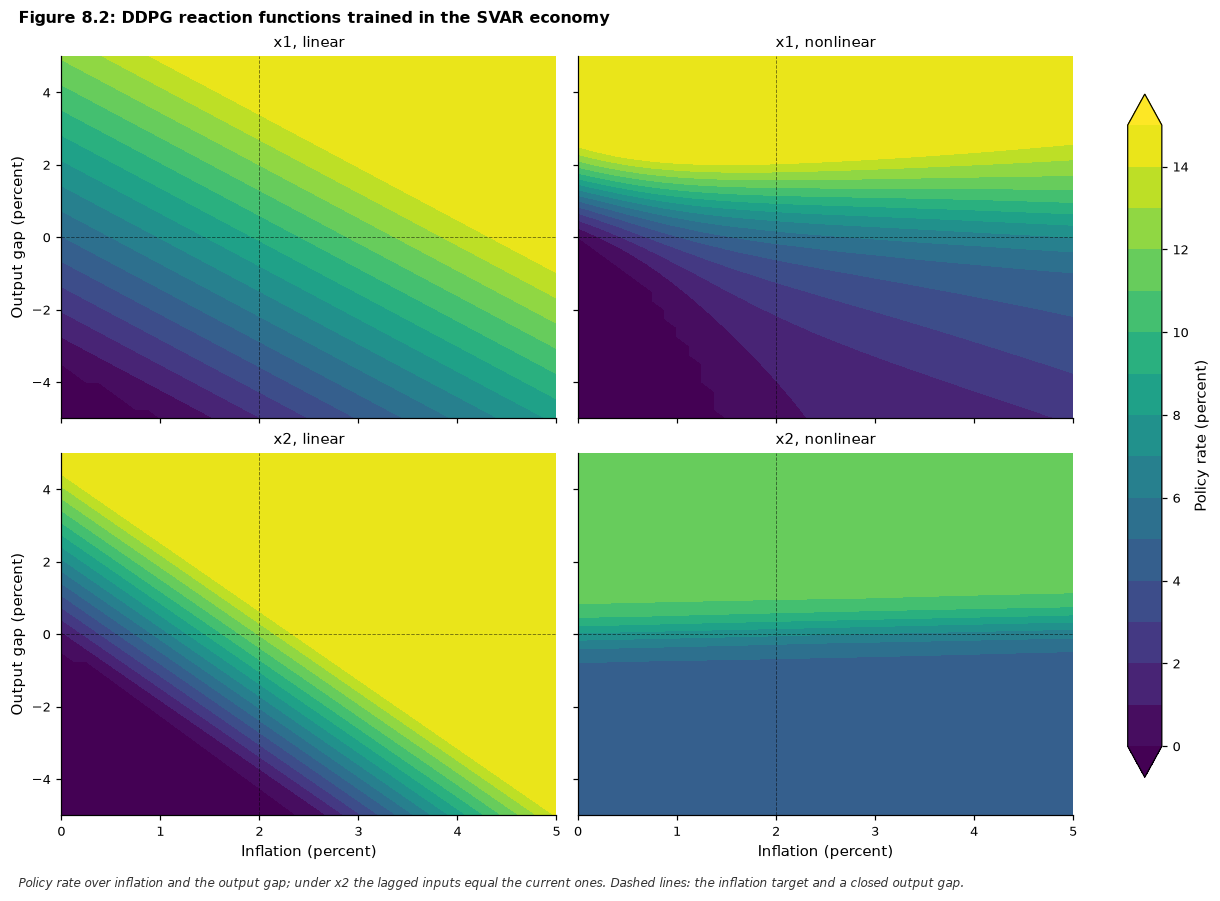

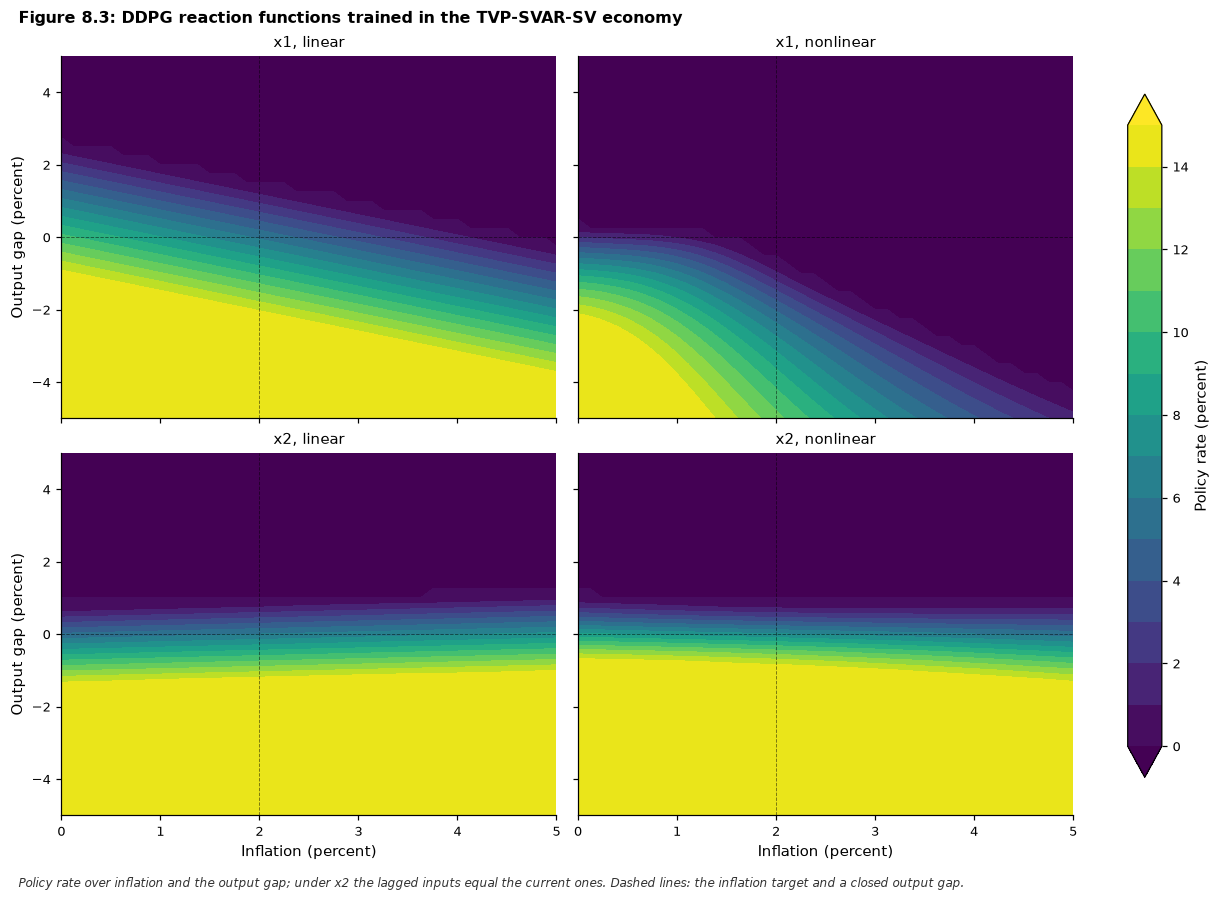

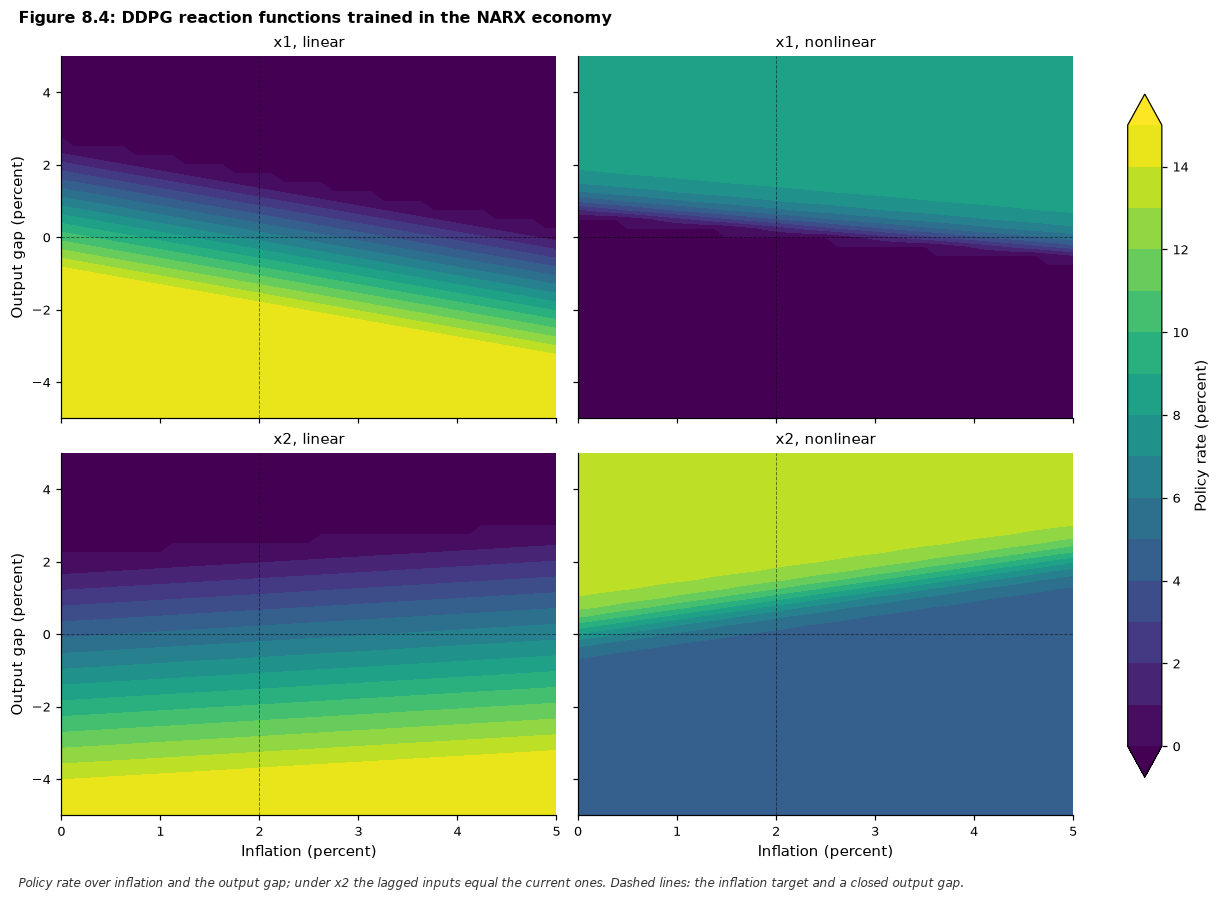

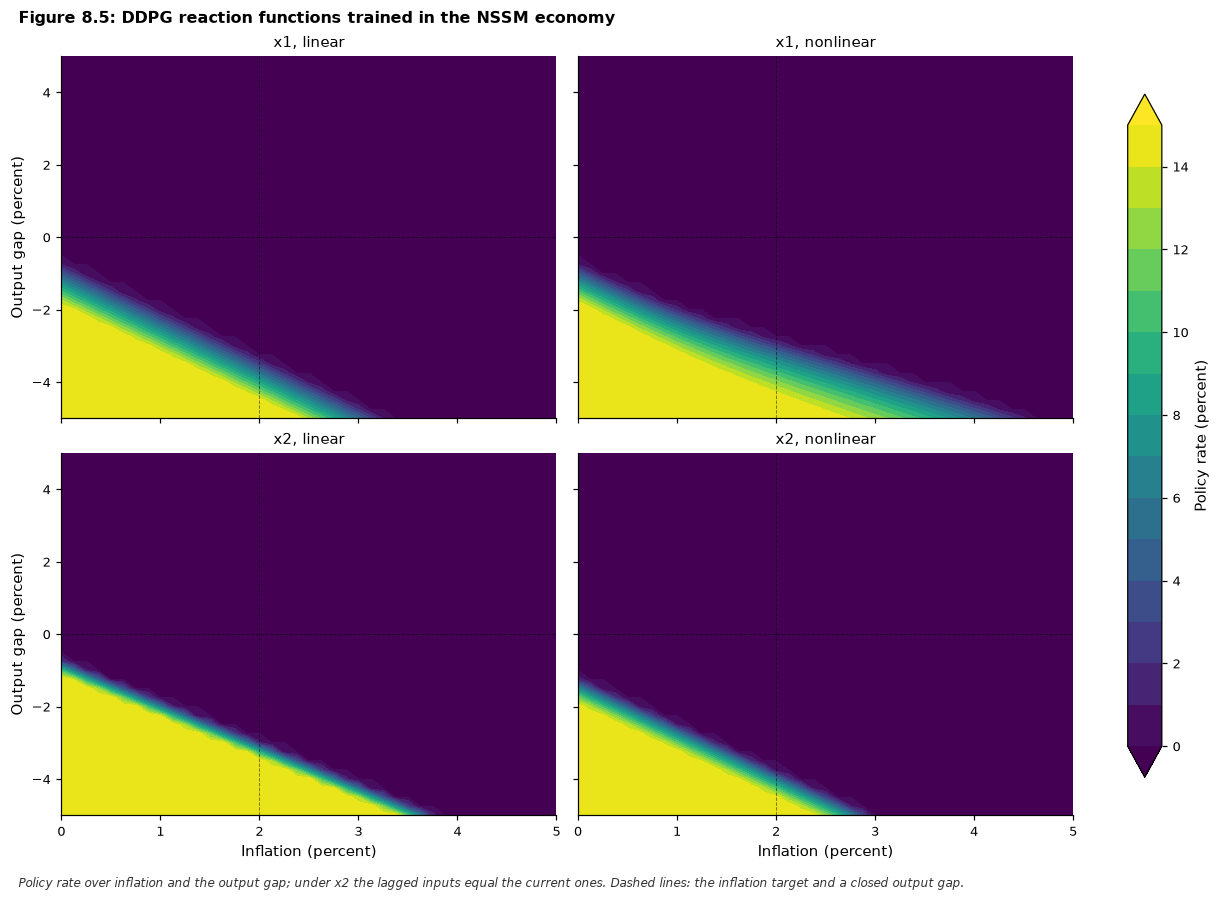

In [17]:
for env_name in lab.env_names:
    panels = {
        f"{c.obs_spec}, {c.variant}": rl.policy_surface(c)
        for c in cells
        if c.env_name == env_name
    }
    fig = plots.policy_surface_grid(panels, rate_max=cfg.action_high, pi_star=cfg.pi_star)
    nb.figure(
        fig,
        f"reaction_functions_{slug(env_name)}",
        f"DDPG reaction functions trained in the {env_name} economy",
        note=(
            "Policy rate over inflation and the output gap; under x2 the lagged inputs equal"
            " the current ones. Dashed lines: the inflation target and a closed output gap."
        ),
    )

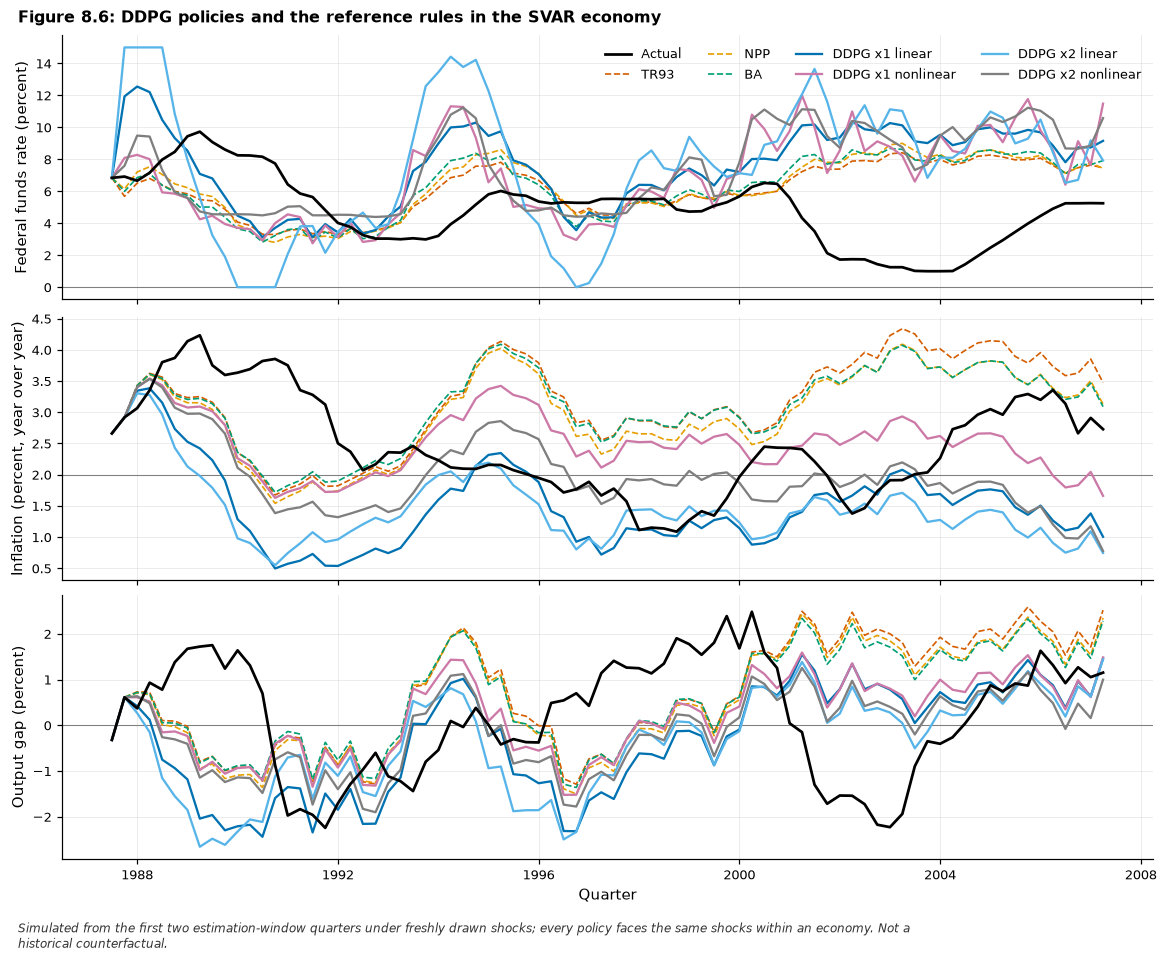

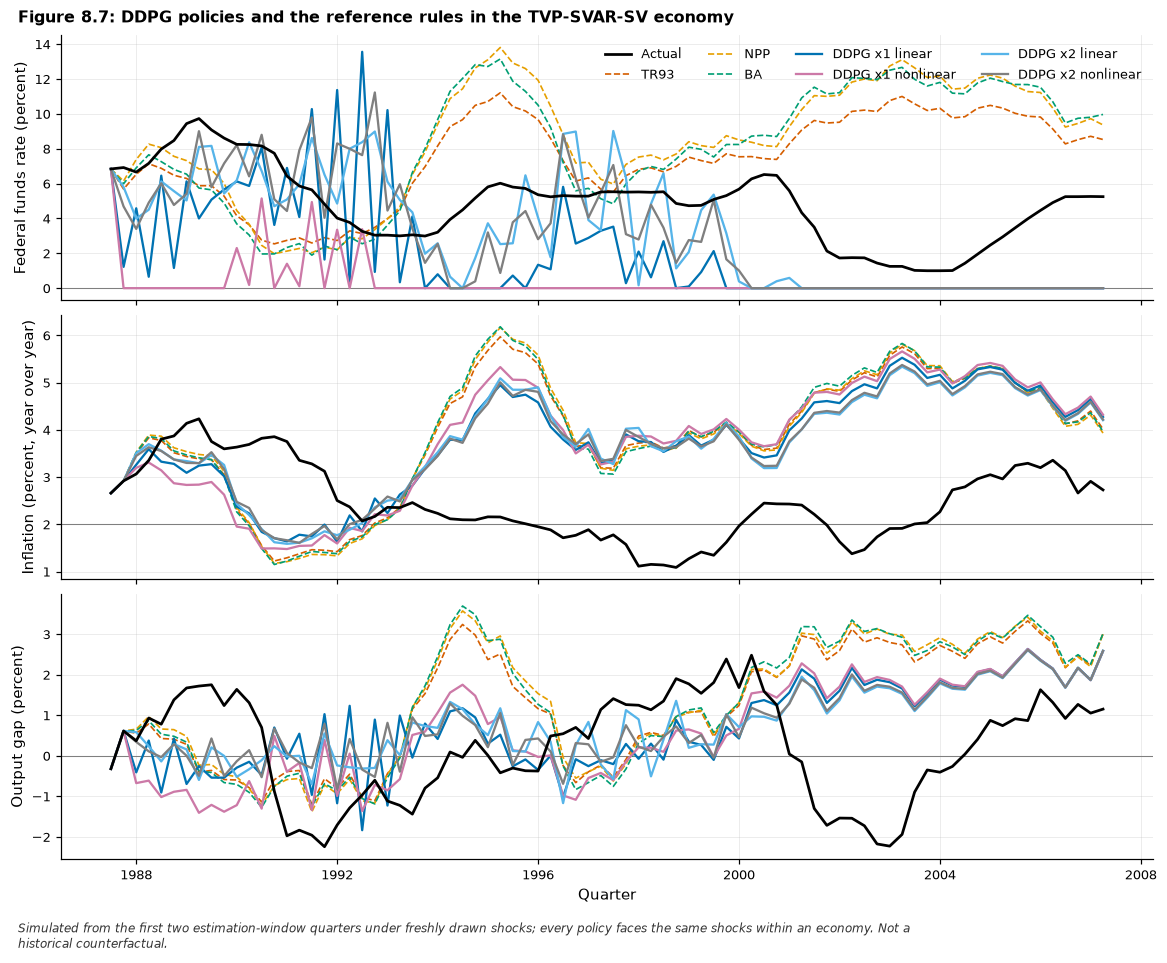

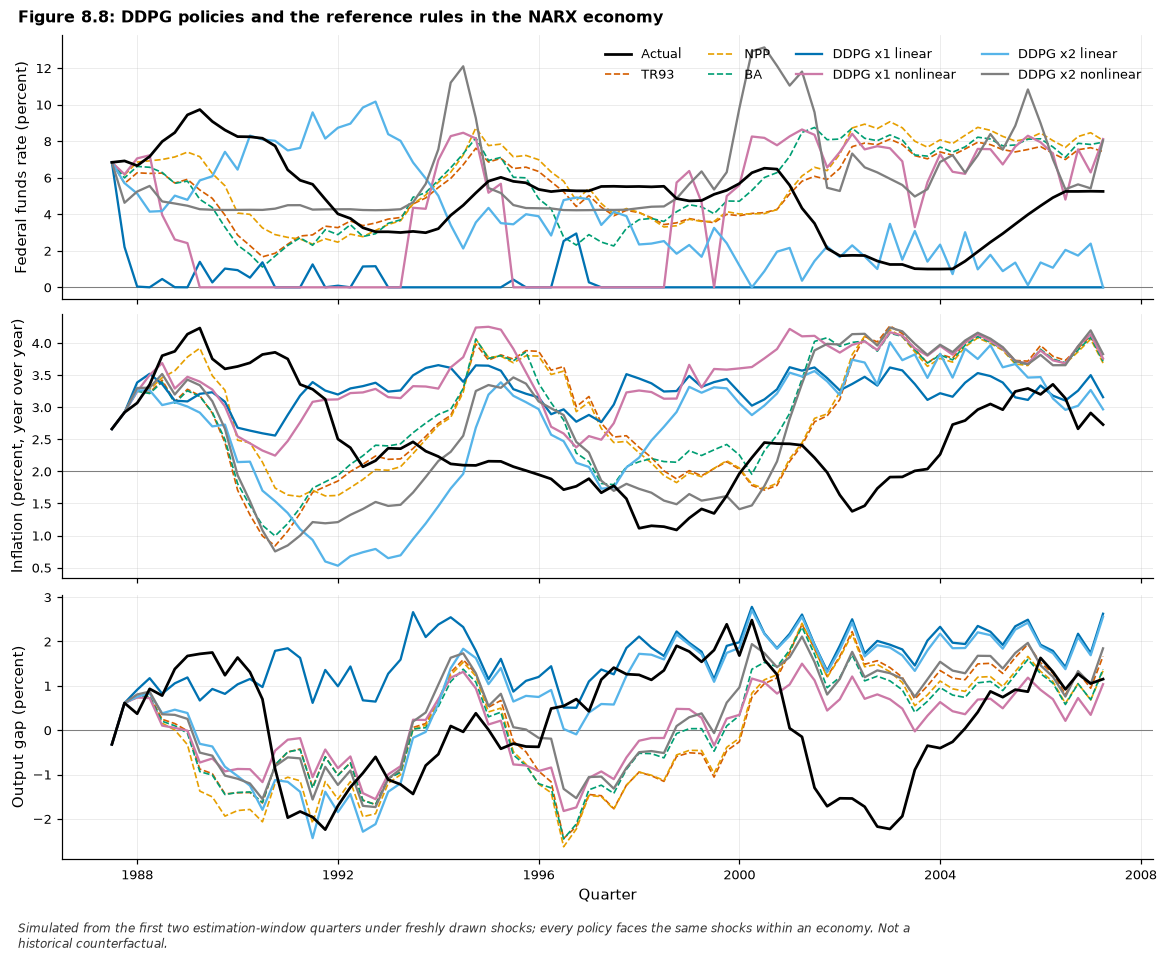

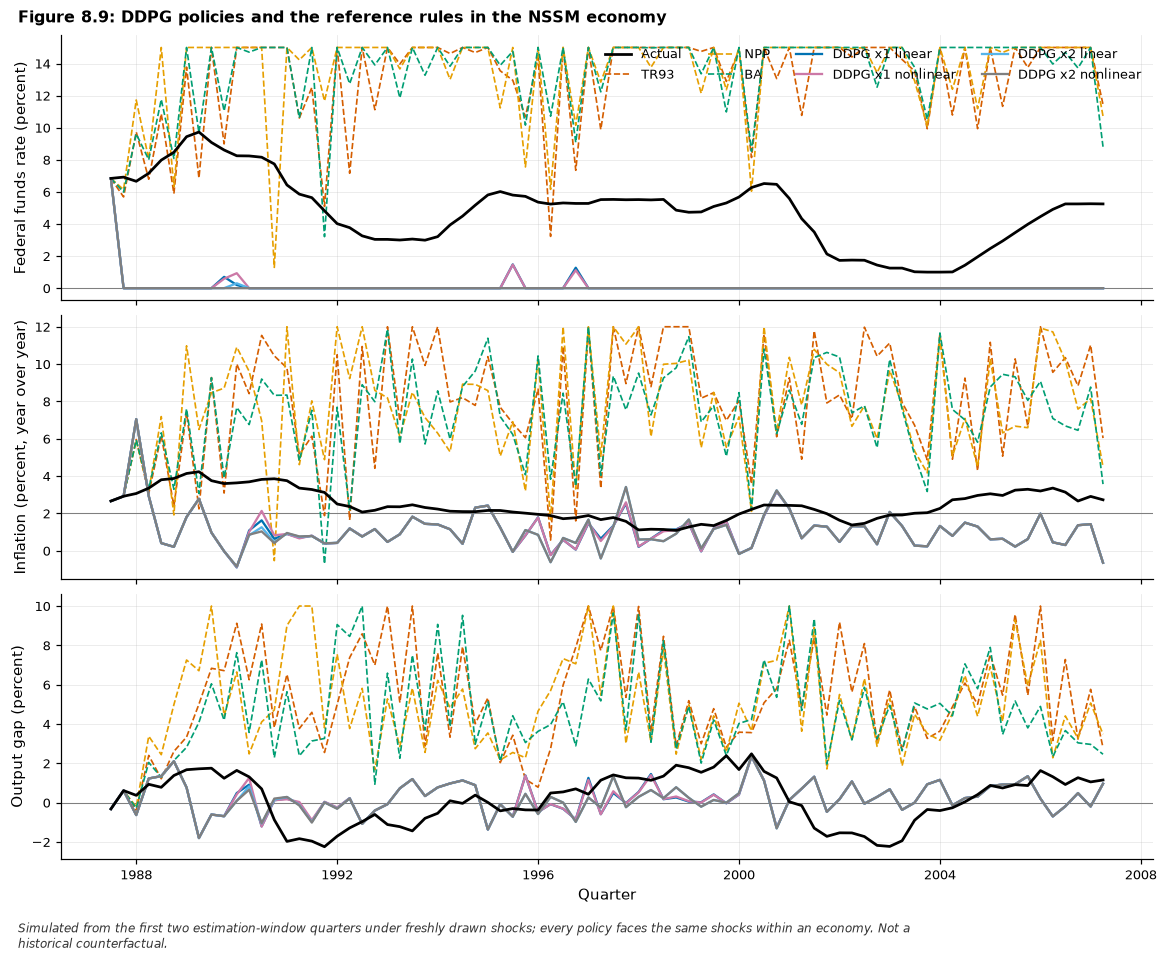

In [18]:
paths_by_economy = {
    env_name: lab.simulate_policies(env_name, cells) for env_name in lab.env_names
}
for env_name, paths in paths_by_economy.items():
    fig = plots.policy_paths(paths, pi_star=cfg.pi_star)
    nb.figure(
        fig,
        f"simulated_paths_{slug(env_name)}",
        f"DDPG policies and the reference rules in the {env_name} economy",
        note=PATH_NOTE,
    )

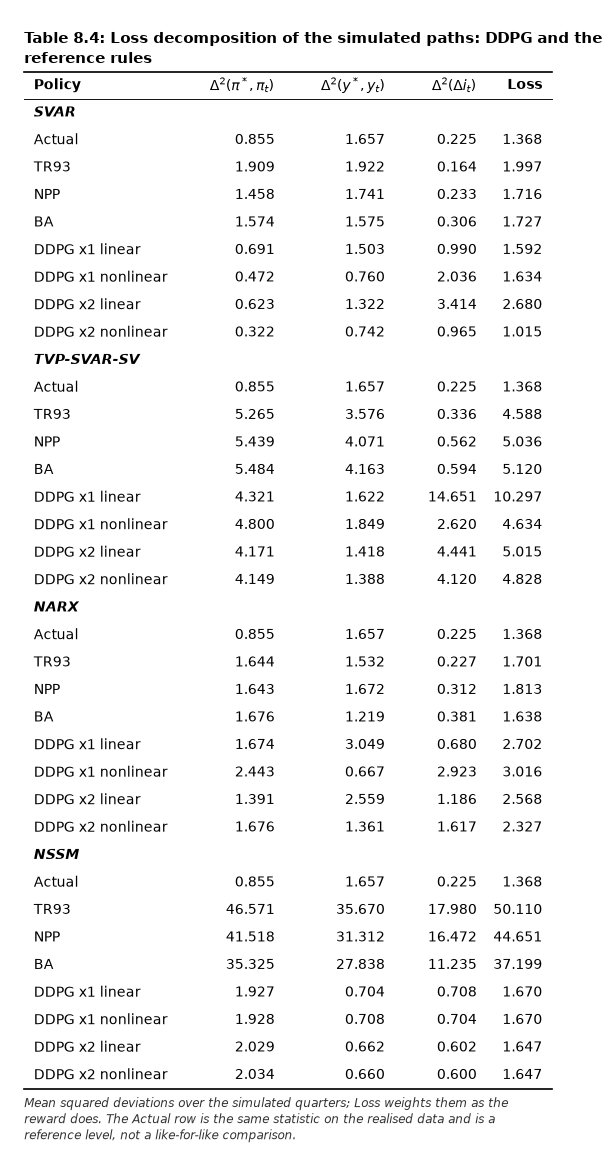

In [19]:
loss_table = lab.loss_table(paths_by_economy).rename(columns=LOSS_COLUMNS)
nb.table(
    loss_table,
    "loss_decomposition",
    "Loss decomposition of the simulated paths: DDPG and the reference rules",
    note=(
        "Mean squared deviations over the simulated quarters; Loss weights them as the reward"
        " does. The Actual row is the same statistic on the realised data and is a reference"
        " level, not a like-for-like comparison."
    ),
)

# References

## 6.2 Papers and books

- Adam, K., & Billi, R. M. (2006). Optimal monetary policy under commitment with a zero bound on nominal interest rates. *Journal of Money, Credit and Banking*, 38(7), 1877-1905.
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Bou, A., Bettini, M., Dittert, S., Kumar, V., Sodhani, S., Yang, X., De Fabritiis, G., & Moens, V. (2023). TorchRL: A data-driven decision-making library for PyTorch. *arXiv preprint arXiv:2306.00577*.
- Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262-302.
- Fraccaro, M., Sonderby, S. K., Paquet, U., & Winther, O. (2016). Sequential neural models with stochastic layers. In *Advances in Neural Information Processing Systems 29* (pp. 2199-2207).
- Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545-1578.
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In *Proceedings of the 13th International Conference on Artificial Intelligence and Statistics* (pp. 249-256).
- Goodfriend, M. (2004). Inflation targeting in the United States? In B. S. Bernanke & M. Woodford (Eds.), *The Inflation-Targeting Debate* (pp. 311-352). University of Chicago Press.
- Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018). Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor. In *Proceedings of the 35th International Conference on Machine Learning* (Vol. 80, pp. 1861-1870).
- Hawkins, R. J., Speakes, J. K., & Hamilton, D. E. (2015). Monetary policy and PID control. *Journal of Economic Interaction and Coordination*, 10(1), 183-197.
- Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *Deutsche Bundesbank Discussion Paper No. 51/2021*.
- Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
- Krishnan, R. G., Shalit, U., & Sontag, D. (2017). Structured inference networks for nonlinear state space models. In *Proceedings of the 31st AAAI Conference on Artificial Intelligence* (pp. 2101-2109).
- Levenberg, K. (1944). A method for the solution of certain non-linear problems in least squares. *Quarterly of Applied Mathematics*, 2(2), 164-168.
- Lillicrap, T. P., Hunt, J. J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D., & Wierstra, D. (2015). Continuous control with deep reinforcement learning. *arXiv preprint arXiv:1509.02971*.
- Lucas, R. E., Jr. (1976). Econometric policy evaluation: A critique. *Carnegie-Rochester Conference Series on Public Policy*, 1, 19-46.
- Marquardt, D. W. (1963). An algorithm for least-squares estimation of nonlinear parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431-441.
- Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., & Riedmiller, M. (2013). Playing Atari with deep reinforcement learning. *arXiv preprint arXiv:1312.5602*.
- Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529-533.
- Nair, V., & Hinton, G. E. (2010). Rectified linear units improve restricted Boltzmann machines. In *Proceedings of the 27th International Conference on Machine Learning* (pp. 807-814).
- Nguyen, D., & Widrow, B. (1990). Improving the learning speed of 2-layer neural networks by choosing initial values of the adaptive weights. In *International Joint Conference on Neural Networks* (Vol. 3, pp. 21-26).
- Nikolsko-Rzhevskyy, A., Papell, D. H., & Prodan, R. (2018). The Taylor principles. *Journal of Macroeconomics*, 55, 14-30.
- Orphanides, A., & Wieland, V. (2000). Inflation zone targeting. *European Economic Review*, 44(7), 1351-1387.
- Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821-852.
- Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Wang, Y., & Januschowski, T. (2018). Deep state space models for time series forecasting. In *Advances in Neural Information Processing Systems 31* (pp. 7796-7805).
- Rotemberg, J. J., & Woodford, M. (1997). An optimization-based econometric framework for the evaluation of monetary policy. *NBER Macroeconomics Annual*, 12, 297-346.
- Rudebusch, G. D., & Svensson, L. E. O. (1999). Policy rules for inflation targeting. In J. B. Taylor (Ed.), *Monetary Policy Rules* (pp. 203-262). University of Chicago Press.
- Sack, B., & Wieland, V. (2000). Interest-rate smoothing and optimal monetary policy: A review of recent empirical evidence. *Journal of Economics and Business*, 52(1-2), 205-228.
- Saxe, A. M., McClelland, J. L., & Ganguli, S. (2014). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. In *International Conference on Learning Representations*.
- Silver, D., Lever, G., Heess, N., Degris, T., Wierstra, D., & Riedmiller, M. (2014). Deterministic policy gradient algorithms. In *Proceedings of the 31st International Conference on Machine Learning* (pp. 387-395).
- Sims, C. A. (2002). Solving linear rational expectations models. *Computational Economics*, 20(1-2), 1-20.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Svensson, L. E. O. (2020). Monetary policy strategies for the Federal Reserve. *International Journal of Central Banking*, 16(1), 133-193.
- Taylor, J. B. (1993). Discretion versus policy rules in practice. *Carnegie-Rochester Conference Series on Public Policy*, 39, 195-214.
- Wang, J., Feinstein, A., & Chen, M. (2026). Reinforcement learning in monetary policy: A comparison of algorithmic approaches. *Stanford University Working Paper*.
- Watkins, C. J. C. H. (1989). *Learning from delayed rewards* (Doctoral dissertation). King's College, University of Cambridge.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3-4), 279-292.
- Wieland, V., Cwik, T., Müller, G. J., Schmidt, S., & Wolters, M. (2012). A new comparative approach to macroeconomic modeling and policy analysis. *Journal of Economic Behavior & Organization*, 83(3), 523-541.
- Wieland, V., Afanasyeva, E., Kuete, M., & Yoo, J. (2016). New methods for macro-financial model comparison and policy analysis. In J. B. Taylor & H. Uhlig (Eds.), *Handbook of Macroeconomics* (Vol. 2, pp. 1241-1319). Elsevier.
- Woodford, M. (2003). *Interest and Prices: Foundations of a Theory of Monetary Policy*. Princeton University Press.

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [20]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_30678/281924391.py:1: UserWarning: 08_rl_ddpg.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
